# Kinetyka chemiczna


### Przykład 1. Kinetyka pierwszego rzędu
Rozważmy reakcję pierwszego rzędu:

$$ A \rightarrow B $$


$$-\frac{d[A]}{dt}=k[A]$$

rozdzielenie zmiennych i całkowanie stronami daje:


$$\int_{[A]_0}^{[A]} - \frac{1}{[A]} d[A] = ln([A]_0) - ln([A])$$

$$\int_{0}^{t}kdt = kt $$

czyli:

$$ ln([A]_0) - ln([A]) = kt $$

lub w innej postaci:

$$[A] = [A]_0\exp(-kt) $$


A teraz całkowanie numeryczne:


Text(0, 0.5, '[A], mol/L')

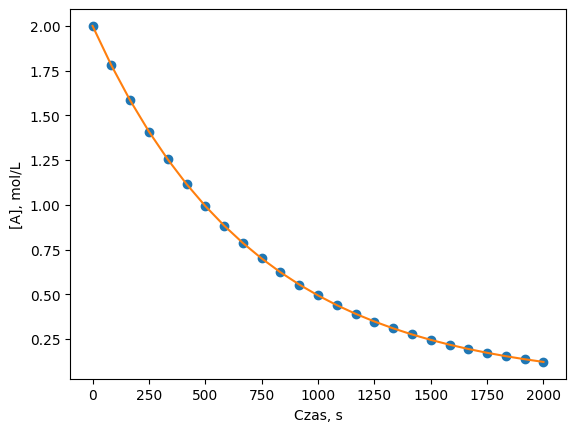

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint



k = 1.4e-3 # 1/s

# A -> B, k
def model(y, t):
    a = y[0]
    dadt = -k*a      # da/dt = ka
    return [dadt]

a0 = 2 # mol/L
initial = [a0]         # [A]0 = 1.2 mol/L

t = np.linspace(0, 2000,25) # ts => time

res = odeint( model, initial, t )
a = res[:,0]

#rozwiazanie analityczne
def y(t):
    return a0*np.exp(-k*t)

plt.plot(t,a,'o')
plt.plot(t,y(t),'-')
plt.xlabel('Czas, s')
plt.ylabel('[A], mol/L')

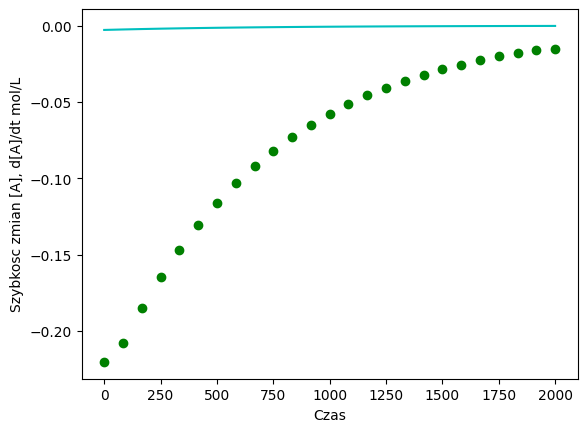

In [2]:
# szybkość zmian stężenia A === "szybkość reakcji" w funkcji czasu

va = k*a

plt.plot(t, -va, 'c-', label='model: dA/dt = -kA')
plt.plot(t, np.gradient(y(t)), 'go', label='numeryczne dA/dt')

plt.xlabel('Czas')
plt.ylabel('Szybkosc zmian [A], d[A]/dt mol/L')

# szybkości va po czasie:
zip(t,va)
# czas, va

In [3]:
#res = odeint( model, initial, [0,40])
#a = res[:,0]
#print (a[1] - a[0])/(t[1]-t[0])

# stężenie A po czasie:
zip(t,a)
# czas, [A]

In [4]:
#print(t[1])

#szybkość chwilowa na początku reakcji (t=...), przybliżenie v0

v0 = (a[0]-a[1])/(t[1]-t[0])
print(v0)

0.0026428370607921733


### Przykład 2. Kinetyka drugiego rzędu

Text(0, 0.5, 'Stezenie reagentow')

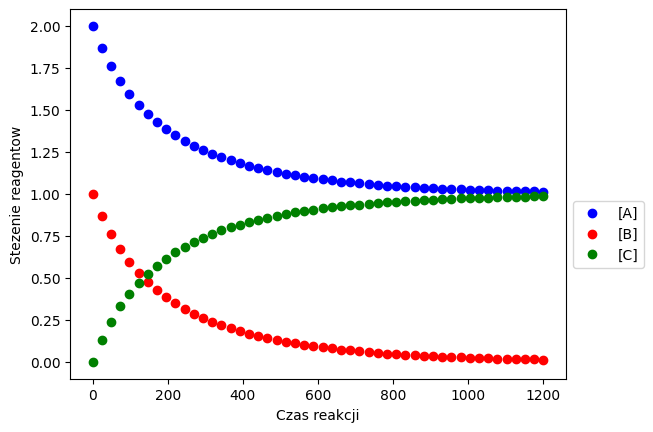

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# A + B -> C

def model(y, t):

    #a,b, c => stężenia [A] [B] [C]
    a = y[0]
    b = y[1]
    c = y[2]

    k1 = 3e-3

    #model kinetyczny
    dadt = -k1*a*b
    dbdt = -k1*a*b
    dcdt = k1*a*b
    return [dadt, dbdt, dcdt]


a0=2
b0=1
c0=0

initial = [a0, b0, c0]
t = numpy.linspace(0, 1200) # ts => time

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]
c = res[:,2]

plt.plot(t,a,'bo', label='[A]')
plt.plot(t,b,'ro', label='[B]')
plt.plot(t,c,'go', label='[C]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')

**Zadanie 1.** Zbadać zachowanie się modelu dla następującego zestawów danych:

a0 | b0 | c0 | k1
--- | --- | --- | ---
1 | 1 | 0 | 3e-3
1 | 0| 0 | 3e-3
2 | 1| 0 | 3e-3



### Przykład 3. Kinetyka psudopierwszego rzędu



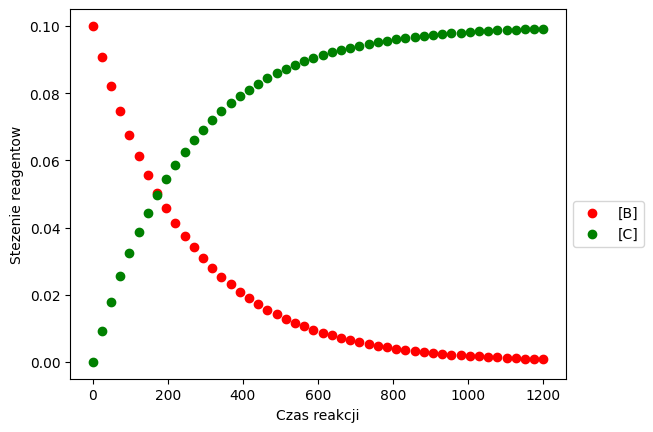

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# A + B -> C

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]
    c = y[2]

    k1 = 1e-4

    #model kinetyczny
    dadt = -k1*a*b
    dbdt = -k1*a*b
    dcdt = k1*a*b
    return [dadt, dbdt, dcdt]


a0=40
b0=0.1
c0=0

initial = [a0, b0, c0]
t = numpy.linspace(0, 1200) # ts => time

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]
c = res[:,2]

#plt.plot(t,a,'bo', label='[A]')
plt.plot(t,b,'ro', label='[B]')
plt.plot(t,c,'go', label='[C]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')
plt.show()

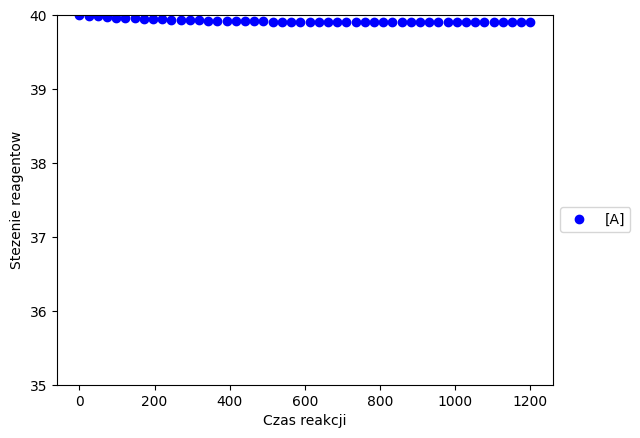

In [7]:
plt.plot(t,a,'bo', label='[A]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')
plt.ylim(35,40) # zakres na osi Y
plt.show()

**Zadanie 2** Jaka jest końcowy stopień konwersji A, a jaki B?

**Zadanie 3** Jak zmieni się szybkość początkowa reakcji gdy [A]0 = 41, 40, 39.8, 39 mol/L ?

In [8]:
alfa_a = 100-100*a[-1]/a[0] #a[-1] ostatni element w vektorze a, -1 to indeks ostatniego elementu
alfa_b = 100-100*b[-1]/b[0]

print("Konwersja końcowa A: {0:.2f}%, konwersja B: {1:.2f}%".format(alfa_a, alfa_b))


Konwersja końcowa A: 0.25%, konwersja B: 99.17%


In [9]:
#szybkość początkowa
v0 = (b[1] - b[0])/(t[1]-t[0])


print(v0)

-0.0003809890652063457


Text(0, 0.5, 'Stezenie reagentow')

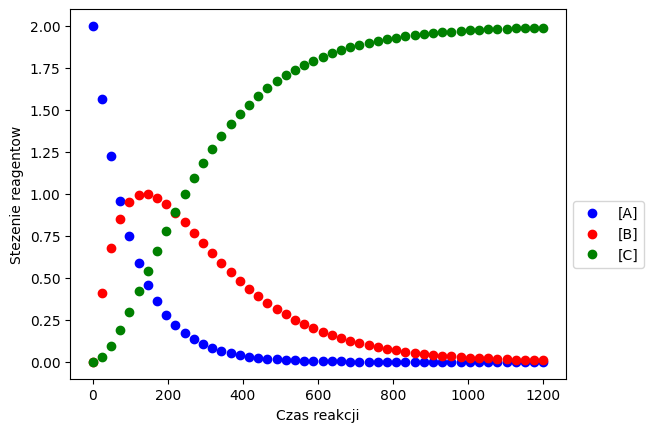

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# A -> B -> C

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]
    c = y[2]

    k1 = 1e-2
    k2 = 5e-3

    #model kinetyczny
    dadt = -k1*a         # da/dt = -k1a
    dbdt = k1*a - k2*b   # db/dt = k1a-k2b
    dcdt = k2*b          # dc/dt = k2b
    return [dadt, dbdt, dcdt]



initial = [2,0,0]
t = numpy.linspace(0, 1200) # ts => time

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]
c = res[:,2]

plt.plot(t,a,'bo', label='[A]')
plt.plot(t,b,'ro', label='[B]')
plt.plot(t,c,'go', label='[C]')
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')

**Zadanie 4.** Opracować model kinetyczny dla reakcji:

1.Równoległych:
$$ A \rightarrow B , k_1=1\cdot10^{-2}$$

$$ A \rightarrow C, k_2=2\cdot10^{-2}$$


2.Równowagowych:

$$ A \rightarrow B, k_1=4\cdot10^{-3} $$
$$ B \rightarrow A, k_2=5\cdot10^{-3} $$

Rozwiązać numerycznie układy równań dla t = 0 ... 1200

### Przykład 4. Kolejne modele kinetyczne


$$ 2A \rightarrow B , k_1=4\cdot10^{-3}$$



Text(0, 0.5, 'Stezenie reagentow')

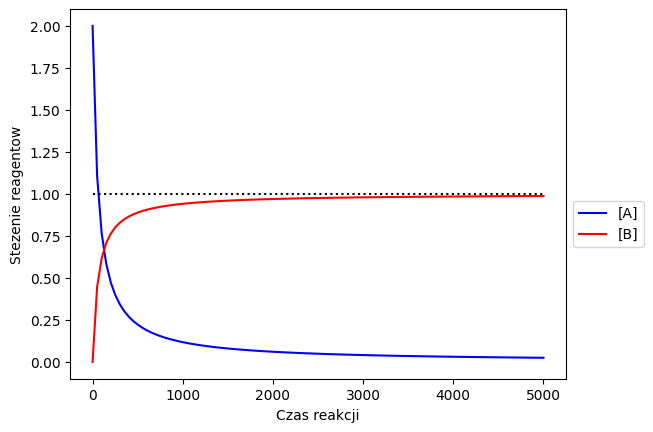

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# 2A ---> B, k1
# co jest równoważne:
# A + A -----> B, k1
# czyli:

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]

    k1 = 4e-3

    #model kinetyczny
    dadt = -k1*a*a - k1*a*a
    dbdt = k1*a*a
    return [dadt, dbdt]


a0=2
b0=0

ts = 0
te = 5000

initial = [a0,b0]
t = numpy.linspace(ts, te,100)

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]


plt.plot(t,a,'b-', label='[A]')
plt.plot(t,b,'r-', label='[B]')
plt.plot((ts, te),(0.5*a0, 0.5*a0),'k:')

plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')


In [12]:
# sprawdzenie --- bilans masy

print(a + 2*b)

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2.]


---

$$ 2A \rightarrow B, k_1=8\cdot10^{-4} $$
$$ B \rightarrow 2A, k_2=2\cdot10^{-4} $$

$$ t = 0 ... 5000 $$

Text(0, 0.5, 'Stezenie reagentow')

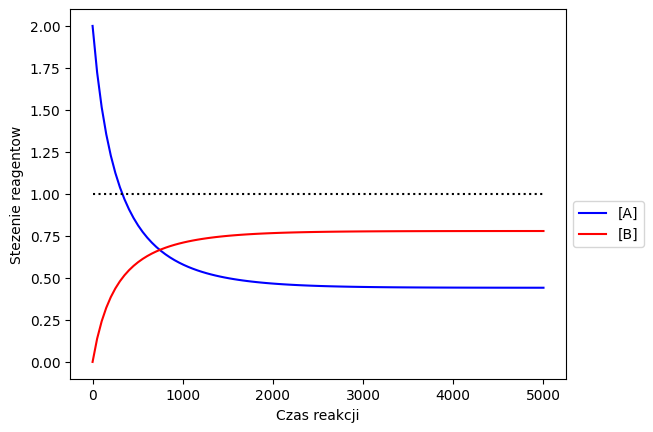

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint


# 2A <---> B, k1, k2
# co jest równoważne:
# A + A -----> B, k1
# B -----> A + A, k2
# czyli:

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]

    k1 = 8e-4
    k2 = 2e-4

    #model kinetyczny
    dadt = -k1*a*a - k1*a*a + k2*b + k2*b
    dbdt = k1*a*a - k2*b
    return [dadt, dbdt]


a0=2
b0=0

ts = 0
te = 5000

initial = [a0,b0]
t = numpy.linspace(ts, te,100)

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]


plt.plot(t,a,'b-', label='[A]')
plt.plot(t,b,'r-', label='[B]')
plt.plot((ts, te),(0.5*a0, 0.5*a0),'k:')

plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')


In [14]:
# sprawdzenie == bilans masy
# czy [A] + 2*[B] = const ?
print(a+2*b)

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2.]


### Przykład 5. Reakcje autokatalityczne

Text(0, 0.5, 'Stezenie reagentow')

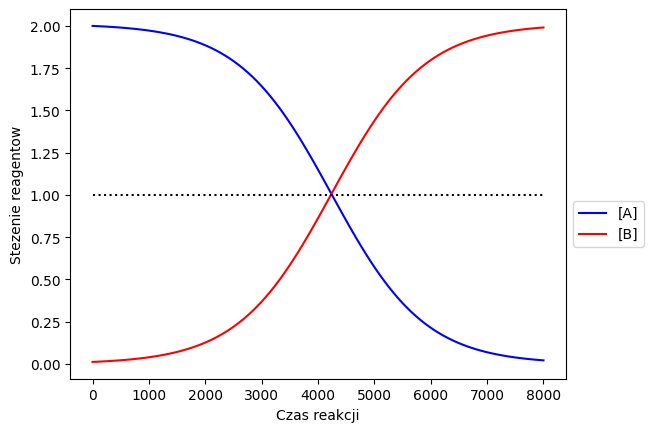

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy
from scipy.integrate import odeint

# Autocatalytic reactions are those in which at least one of the products is a reactant.
# A + B ---> 2B k1

k1 = 6e-4

def model(y, t):

    #a,b => stężenia [A] [B]
    a = y[0]
    b = y[1]

    #model kinetyczny
    dadt = -k1*a*b
    dbdt =  k1*a*b
    return [dadt, dbdt]


a0=2
b0=0.012

ts = 0
te = 8000

initial = [a0,b0]
t = numpy.linspace(ts, te,100)

res = odeint( model, initial, t )
a = res[:,0]
b = res[:,1]


plt.plot(t,a,'b-', label='[A]')
plt.plot(t,b,'r-', label='[B]')
plt.plot((ts, te),(0.5*a0, 0.5*a0),'k:')

plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Czas reakcji')
plt.ylabel('Stezenie reagentow')


**Zadanie 5.** Prześledzić zależność szybkości reakcji autokatalitycznej v w funkcji czasu (sporządzić wykres). Czy zaobserwowane zjawisko jest sprzeczne z prawami kinetyki chemicznej?

Odpowiedź jest poniżej - zajrzeć w ostateczności ...

Text(0, 0.5, 'Szybkosc reakcji autokatalitycznej, mol/Ls')

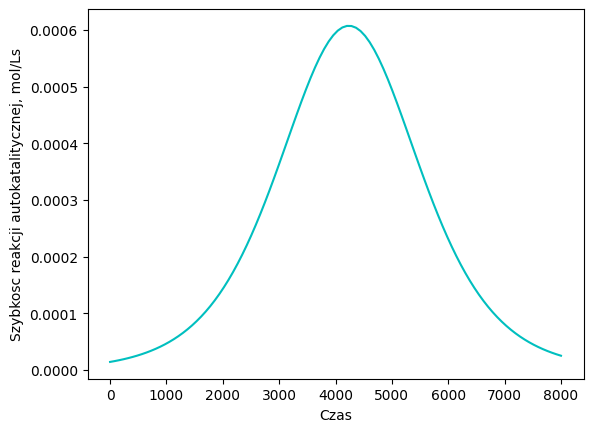

In [18]:
plt.plot(t,k1*a*b, 'c-')
plt.xlabel('Czas')
plt.ylabel('Szybkosc reakcji autokatalitycznej, mol/Ls')